In [110]:
# Zelle 1: Notwendige Imports

import pandas as pd
import sqlite3
import openslide
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

print("Module importiert. Bereit zum Start.")

Module importiert. Bereit zum Start.


In [124]:
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import random

print("Module importiert. Bereit zum Start.")

Module importiert. Bereit zum Start.


In [125]:
# Zelle 2: Pfade und Konfiguration

# Pfade zu den Daten
image_folder = Path('../images/')
annotation_file = Path('../images/MIDOGpp.sqlite')
slide_info_file = Path('../datasets_xvalidation.csv') # Diese CSV enthält die Dateinamen

# Überprüfen, ob alles da ist
assert image_folder.exists(), f"FEHLER: Bild-Ordner '{image_folder}' nicht gefunden!"
assert annotation_file.exists(), f"FEHLER: Annotations-DB '{annotation_file}' nicht gefunden!"
assert slide_info_file.exists(), f"FEHLER: Slide-Info CSV '{slide_info_file}' nicht gefunden!"

print("Pfade sind korrekt.")

Pfade sind korrekt.


In [126]:
# Zelle 3: Zufälliges Bild auswählen

# Lade die Slide-Informationen
slides_df = pd.read_csv(slide_info_file, delimiter=";")
print(f"Insgesamt {len(slides_df)} Slides im Datensatz gefunden.")

# Wähle eine zufällige Slide aus der Liste
random_slide_info = slides_df.sample(1).iloc[0]
slide_uid = random_slide_info['Slide']
slide_tumortyp = random_slide_info['Tumor']

print(f"\nZufällige Slide ausgewählt:")
print(f"  -> UID: {slide_uid}")
print(f"  -> Tumortyp: {slide_tumortyp}")

Insgesamt 503 Slides im Datensatz gefunden.

Zufällige Slide ausgewählt:
  -> UID: 364
  -> Tumortyp: human neuroendocrine tumor


In [127]:
# =================================================================================
# Zelle 4: Bildpfad und Annotationen laden (mit robuster Datentyp-Behandlung)
#
# Logik:
# 1. Wandelt die numerische 'slide_uid' aus der vorherigen Zelle IMMER in einen STRING um.
# 2. Führt die SQL-Abfragen mit diesem STRING durch, um Fehler durch die
#    "NUMERIC Affinity" von SQLite zu vermeiden.
# =================================================================================

# Verbindung zur SQLite-Datenbank herstellen
conn = sqlite3.connect(annotation_file)
cursor = conn.cursor()

# === ROBUSTE VERGLEICHSLOGIK ===
# Wandle die numerische UID in einen String um, um einen sicheren Text-Vergleich zu erzwingen.
uid_to_search_as_string = str(slide_uid)

# 1. Finde den Dateinamen der Slide anhand der STRING-UID
# Wir holen uns auch die UID aus der DB zurück, um sie konsistent weiterzuverwenden
cursor.execute("SELECT filename, uid FROM Slides WHERE uid = ?", (uid_to_search_as_string,))
result = cursor.fetchone()

if result is None:
    # Dieser Fehler sollte jetzt nicht mehr auftreten, wenn die UID existiert.
    raise ValueError(f"Konnte keine Slide mit UID '{uid_to_search_as_string}' in der Datenbank finden.")

original_filename, db_uid = result
slide_basename = Path(original_filename).stem
slide_filename = f"{slide_basename}.tiff"
image_path = list(image_folder.glob(f"**/{slide_filename}"))[0]

print(f"Dateipfad gefunden: {image_path.name}")

# 2. Lade alle Annotationen für diese Slide
#    WICHTIG: Wir verwenden hier die 'db_uid', die wir gerade aus der DB gelesen haben.
#    Das ist die sicherste Methode, um die korrekte Referenz zu haben.
query = """
SELECT coordinateX, coordinateY, agreedClass
FROM Annotations_coordinates
JOIN Annotations ON Annotations_coordinates.annoId = Annotations.uid
WHERE Annotations.slide = ? AND Annotations.agreedClass = 1
"""
cursor.execute(query, (db_uid,))
annotations = cursor.fetchall()
conn.close()

print(f"Insgesamt {len(annotations)} mitotische Figuren in dieser Slide gefunden.")

Dateipfad gefunden: 364.tiff
Insgesamt 23 mitotische Figuren in dieser Slide gefunden.


Flaches TIFF erkannt (nur eine Seite). Lade Bild...
Bild erfolgreich mit tifffile geladen. Shape: (5412, 7215, 4)


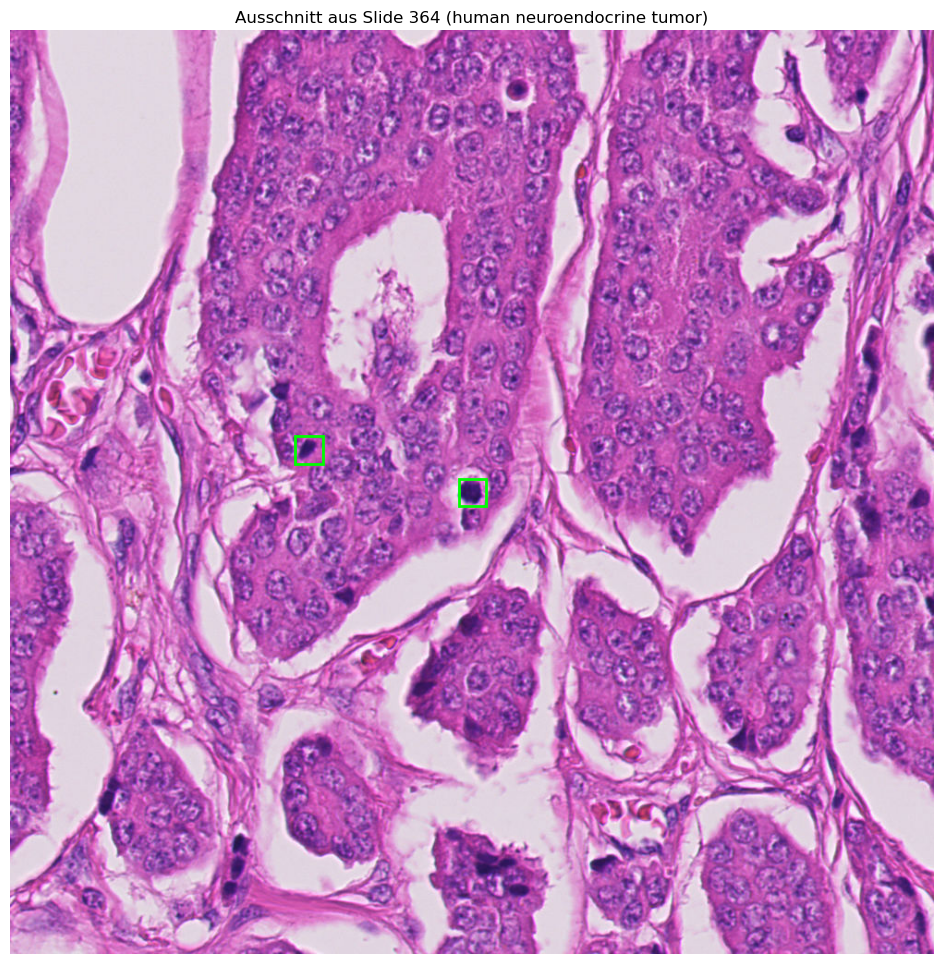

In [128]:
# =================================================================================
# Zelle 5: Bild anzeigen (mit noch robusterem tifffile-Handling)
# =================================================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import tifffile as tiff
import numpy as np

if not annotations:
    print("Keine Annotationen zum Anzeigen gefunden.")
else:
    try:
        with tiff.TiffFile(str(image_path)) as tif:
            # === ROBUSTERE PRÜFUNG AUF PYRAMIDALE TIFFS ===
            # Anstatt .is_pyramidal zu verwenden, prüfen wir, ob es mehrere "Seiten" gibt.
            # Jede Seite in einem pyramidalen TIFF ist eine Auflösungsstufe.
            if len(tif.pages) > 1:
                print("Pyramidales TIFF erkannt (mehrere Seiten gefunden). Lade höchste Auflösung (Seite 0)...")
                wsi_level0 = tif.pages[0].asarray()
            else:
                print("Flaches TIFF erkannt (nur eine Seite). Lade Bild...")
                wsi_level0 = tif.asarray()
        
        print("Bild erfolgreich mit tifffile geladen. Shape:", wsi_level0.shape)
        # ---------------------------------------------------

        # Wir zentrieren den Ausschnitt um die erste gefundene Mitose
        center_x, center_y, _ = annotations[0]
        
        # Definiere die Größe des Ausschnitts
        patch_width = 1000
        patch_height = 1000
        
        # Berechne die obere linke Ecke des Ausschnitts
        location_x = max(0, int(center_x - patch_width / 2))
        location_y = max(0, int(center_y - patch_height / 2))
        
        # Schneide den Patch aus dem bereits geladenen NumPy-Array aus
        patch = wsi_level0[location_y : location_y + patch_height, 
                           location_x : location_x + patch_width]

        # --- Jetzt zeichnen wir alles ---
        fig, ax = plt.subplots(1, figsize=(12, 12))
        ax.imshow(patch)
        ax.set_title(f"Ausschnitt aus Slide {slide_uid} ({slide_tumortyp})")

        # Gehe durch alle Annotationen und zeichne die, die im Patch sichtbar sind
        count_visible = 0
        for x, y, _ in annotations:
            relative_x = x - location_x
            relative_y = y - location_y

            if 0 <= relative_x < patch_width and 0 <= relative_y < patch_height:
                count_visible += 1
                rect = Rectangle((relative_x - 15, relative_y - 15), 30, 30, linewidth=2, edgecolor='lime', facecolor='none')
                ax.add_patch(rect)
        
        ax.set_xlabel(f"{count_visible} von {len(annotations)} Mitosen in diesem Ausschnitt sichtbar.")
        plt.axis('off')
        plt.show()

    except Exception as e:
        print(f"Ein Fehler ist aufgetreten: {e}")